##Parâmetros da Simulação

In [1]:
import numpy as np
import random
K= 512 #tamanho da chave
L = 412  #tamanho da tag e da mensagem
N = 10**3
rho_s = np.sqrt(0.985)  # alocação de potência para a mensagem
snr_db = 10
eta = 0.0000001 #1% default

# Mensagem e Modulação BPSK#


In [2]:
#mensagem modulada de comprimento K com alfabeto de [1,-1]
def modulator_bpsk(L, seed=None):
    s_bin = np.random.randint(0, 2, size=L)
    s_bpsk = 1 - 2 * s_bin  # mapeia 0→+1, 1→-1
    return s_bin, s_bpsk


#Geração das TAGs


In [3]:
a, b, c = 6, 1, 1
def Mfunc(x, K):
    return (a * x**2 + b * x + c) % (1 << K)

def tentmap(x, beta=1e-6):
    if x is None:
        x = np.random.uniform(-1, 1)
    if x < beta:
        return 2.0 / (beta + 1) * x + (1 - beta) / (beta + 1)
    else:
        return 2.0 / (beta - 1) * x - (beta + 1) / (beta - 1)

def orbit(x0, steps):
    """Gera uma órbita com pré-alocação de array (mais rápido que append)."""
    x = x0
    orb = np.empty(steps, dtype=np.float64)
    for i in range(steps):
        x = tentmap(x)
        orb[i] = x
    return orb

def binary_to_int_fast(binary_array):
    """Converte vetor binário para inteiro de forma eficiente usando packbits."""
    packed = np.packbits(binary_array.astype(np.uint8))
    return int.from_bytes(packed.tobytes(), 'big')

# Geração de TAG de comprimento L com 1 órbita por símbolo (versão otimizada)
def generate_tag(L, K, bits_msg, chave, x0=None):
    sigma = K - L  # pontos a descartar
    if x0 is None:
        m_filled = np.resize(bits_msg, K)
        s_xor_k = np.bitwise_xor(m_filled, chave)
        xor_value = binary_to_int_fast(s_xor_k)
        xi = Mfunc(xor_value, K=K)
        x0_norm = (xi / (2**K - 1)) * 2 - 1
    else:
        x0_norm = x0
    orb = orbit(x0_norm, K)  # gera K pontos
    orb_descarte = orb[sigma:]  # descarta os sigma pontos
    return orb_descarte


In [4]:
import time
chave = np.random.randint(0, 2, K, dtype=np.uint8)
bits_msg, bpsk_msg = modulator_bpsk(L)
# aquecimento
_ = generate_tag(L, K, bits_msg, chave)
start = time.perf_counter()
for _ in range(100):
    tag = generate_tag(L, K, bits_msg, chave)
elapsed_ms = (time.perf_counter() - start) * 1000
print(f"Tempo para 100 tags: {elapsed_ms:.2f} ms")
print("Media tag:", np.mean(tag))
print("Variancia :", np.var(tag))
print("Media do quadrado/potencia/var/energia media:", np.mean(tag**2))
print("energia", np.sum(tag**2))
print("Potencia*L = energia", np.mean(tag**2) * L)


Tempo para 100 tags: 6.58 ms
Media tag: 0.025420320955582335
Variancia : 0.3174499354884856
Media do quadrado/potencia/var/energia media: 0.3180961282059704
energia 131.0556048208598
Potencia*L = energia 131.0556048208598


In [5]:
""" variavel em analise: tau|H0
media = np.mean(tau|H0)                # E[tau|H0] #valor esperado
energia_media = np.mean(tau_H0**2)     # E[tau^2|H0] #potencia
variancia = energia_media - media**2   # Var[tau|H0]
"""

rho_t = np.sqrt((1 - rho_s**2) / np.mean(tag**2))
y= ((1-rho_s)/rho_t)*bpsk_msg
tau_H0 = np.sum(y*tag) #variavel
print(tau_H0)
E_tau_H0 = np.mean(tau_H0) #Valor esperado
print(E_tau_H0)
Pot_tau = np.mean((y*tag)**2) #media da energia (soma dos valores quadraticos) =potencia
print(Pot_tau)
var= np.var(y*tag) #var é a do ruido
print(var)


0.35273230589347127
0.35273230589347127
0.0003823170956799102
0.0003815841090670053


#Transmissão#


In [6]:
# --- Energia da TAG ---
def compute_tag_power(tag):
    """
    Calcula a energia média - POTENCIA - de uma única tag (um vetor).
    """
    return np.mean(tag**2) #media da energia do sinal é a potencia média, precisa ser para que rho_s**2 + rho_t**2 =1

def get_rayleigh_sample(sigma_h=(1/np.sqrt(2))):
    """
    Gera um único valor de ganho Rayleigh (h) com sigma_h^2 = E[h^2]/2.
    Este valor é constante durante todo o tempo de coerência de uma transmissão.
    """
    # ganho é a magnitude de duas variaveis gaussianas independentes X e Y
    # Retorna um ESCALAR 
    h = np.random.rayleigh(sigma_h)
    return h
# --- Combina mensagem e tag ---
def combine_message_tag(s, tag, rho_s):
    """
    Combina uma mensagem BPSK (s) e uma tag (tag) em um único sinal x.
    Multiplica o sinal combinado por um ganho Rayleigh ESCALAR h.
    """
    Ptag = compute_tag_power(tag)   # E[tag^2]
    rho_t = np.sqrt((1 - rho_s**2) / Ptag)  # normalização pela potencia da media tag
    # Combinação: multiplica toda a mensagem+tag por um único h (escalar)
    s = np.array(s)
    tag = np.array(tag)
    x = (rho_s * s) + (rho_t * tag)

    return x, rho_t


# --- Ruído AWGN ---
def gen_awgn(snr_db, N):
    """
    Gera ruído gaussiano branco de tamanho N para um SNR dado.
    """
    snr_linear = 10**(snr_db / 10)
    Es = 1  # energia média do BPSK fixada
    sigma2w = Es / snr_linear  # variância do ruído
    noise = np.random.normal(0, np.sqrt(sigma2w), N)
    return sigma2w, noise


# --- Canal AWGN ---
def add_noise(x, snr_db, h):
    """
    Adiciona ruído AWGN a um único sinal x.
    """
    sigma2w, noise = gen_awgn(snr_db, len(x))
    y = (h * x) + noise
    return y, noise


##Recepção

In [7]:
def detect_tag(y, h, s, t_ref, rho_s, rho_t):
    """
    Calcula a estatística de decisão para UMA transmissão com canal Rayleigh.
    Remove o efeito do ganho h (escalar) antes de processar.
    """
    # Remove o ganho Rayleigh h (escalar) e a contribuição da mensagem
    y_minus_msg = ((y / h) - (rho_s * s)) / rho_t

    # Correlação com TAG legítima (esperada)
    stat = np.sum(y_minus_msg * t_ref)

    return stat


# Limiar de decisão e Matriz de Confusão

In [ ]:
'''import numpy as np
from scipy.stats import norm

def find_threshold_to_reduce_fp(stat_H1, stat_H0, eta, plot=True):
    """Encontra um threshold que satisfaça FP <= eta e maximize TP.

    Estratégia híbrida (mais robusta para Rayleigh+AWGN):
    - Ajuste Normal em `stat_H0` para estimar um limiar teórico: mu0 + sigma0 * norm.isf(eta)
    - Quantil empírico de `stat_H0` para garantir FP empiricamente <= eta
    - Usa o limiar conservador: max(quantil_empírico, limiar_normal)

    Retorna um escalar numérico (ou None se `stat_H0` vazio).
    """
    stat_H0 = np.asarray(stat_H0).ravel()
    stat_H1 = np.asarray(stat_H1).ravel()

    if stat_H0.size == 0:
        return None

    # Estatísticas empíricas de H0
    mu0 = np.mean(stat_H0)
    sigma0 = np.std(stat_H0, ddof=1) if stat_H0.size > 1 else 0.0

    # Limiar baseado no ajuste normal (teórico)
    if sigma0 > 0:
        tau_norm = mu0 + sigma0 * norm.isf(eta)
    else:
        tau_norm = stat_H0.max() + np.finfo(float).eps

    # Limiar empírico (quantil) garantindo FP <= eta na amostra
    # Para evitar problemas com eta abaixo da resolução amostral usamos índice conservador
    sorted_h0 = np.sort(stat_H0)
    rank = int(np.ceil((1 - eta) * stat_H0.size)) - 1
    rank = max(0, min(rank, stat_H0.size - 1))
    tau_emp = sorted_h0[rank]

    # Escolhe limiar conservador
    tau = max(tau_emp, tau_norm)

    # Opcional: relatório rápido quando solicitado
    if plot:
        fp_emp = np.mean(stat_H0 >= tau)
        tp_emp = np.mean(stat_H1 >= tau) if stat_H1.size > 0 else None
        print(f"Threshold chosen: {tau:.4f} | FP_emp={fp_emp:.4e} | TP_emp={tp_emp}")

    return float(tau)'''

In [9]:
#Decodificador da dissertação:
from scipy.stats import norm
from scipy.special import erfc
import pytest

def Qfunc(x):
    """ Q function """
    return (0.5)*erfc(x/np.sqrt(2))

def thresh(stdDev,mean,alpha):
#    """ Finds the decision threshold for the hypothesis test """
    threshold = 0
    while Qfunc((threshold-mean)/stdDev) > alpha:
        threshold += 0.1
    return threshold
#def thresh(stdDev, mean, alpha):
#    return norm.isf(alpha) * stdDev + mean

#def thresh(std, mean, alpha):
#    return mean + std * norm.isf(alpha)

def tauVarCalc(sigma2w, len_message, rho_t, tag, h):
    """
    Calcula a variância da estatística τ com canal Rayleigh.
    
    PARÂMETRO h: Ganho Rayleigh ESCALAR para esta transmissão.
    """
    sigma2tag = np.var(tag)
    # h é um escalar, então usamos diretamente
    tauVar = (sigma2tag * sigma2w * len_message) / ((rho_t * h)**2)
    return tauVar

def threshold_decision(sigma2w, len_message, rhot, tag, eta, h):
    """
    Decide entre H1 (TAG legítima) e H0 (sem TAG ou falsa),
    com base no limiar calculado pela expressão:
    Q(tau_i / sigma^2_vi) < eta
    """
    sigma2_v = tauVarCalc(sigma2w, len_message, rhot, tag, h)
    tau0 = thresh(np.sqrt(sigma2_v), 0, eta)
    return tau0


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def compute_confusion_matrix(stat_H1, stat_H0, tau):

    y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
    y_scores = np.concatenate([stat_H1, stat_H0])

    # Se tau for um único valor, repete para todas as transmissões
    if np.isscalar(tau):
        tau_vec = np.full_like(y_scores, fill_value=tau, dtype=float)
    else:
        tau_vec = np.array([tau[i % len(tau)] for i in range(len(y_scores))])

    # Aplica thresholds por transmissão
    y_pred = (y_scores >= tau_vec).astype(int)

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()

    cm_normalized = cm.astype('float') / len(stat_H0)

    print(f"TP: {TP/len(stat_H1)}, FP: {FP/len(stat_H0)}, TN: {TN/len(stat_H0)}, FN: {FN/len(stat_H1)}")
    print(f"Accuracy: {(TP + TN) / len(y_true):.3f}")
    print(f"False Positive Rate: {FP:.3f}")
    print(f"False Negative Rate: {FN:.3f}")

    # Exibe a matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["H0", "H1"])
    disp.plot(cmap='Blues')
    plt.grid(False)
    plt.title("Matriz de Confusão")
    plt.show()


#Teste de Hipótese

In [11]:
def simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave, sigma2w, eta):
    """
    Simulação Monte Carlo com canal Rayleigh fading.

    H1: Transmissão legítima (mensagem + tag através do canal com ganho h)
    H0: Transmissão falsa do atacante externo (mensagem SEM tag, canal INDEPENDENTE h_fake)

    O ganho Rayleigh h é constante durante o tempo de coerência de UMA transmissão,
    mas varia entre transmissões. H0 e H1 usam canais INDEPENDENTES (h ≠ h_fake).

    Retorna: (all_stat_H1, all_stat_H0, tau_vec) onde `tau_vec` contém um limiar
    por transmissão calculado condicionando em `h` (mais preciso para Rayleigh).
    """
    all_stat_H1 = []
    all_stat_H0 = []
    tau_vec = []

    for n in range(N):
        # --- 1. Mensagem e modulação ---
        bits_msg, bpsk_msg = modulator_bpsk(L)

        # --- 2. Geração da TAG legítima ---
        tag_legit = generate_tag(L, K, bits_msg, chave)

        # --- 3. Gera um ESCALAR h (Rayleigh) para transmissão legítima H1 ---
        # Este valor é constante durante todo o tempo de coerência
        h = get_rayleigh_sample()
        #h=1

        # --- 4. Combinação mensagem + TAG legítima ---
        x_tag, rho_t = combine_message_tag(bpsk_msg, tag_legit, rho_s)

        # --- 5. Canal AWGN + Rayleigh para H1 ---
        y_legit, noise = add_noise(x_tag, snr_db, h)

        # --- 6. Decisão sob H1 ---
        tau_H1 = detect_tag(y_legit, h, bpsk_msg, tag_legit, rho_s, rho_t)

        # --- 7. Geração de mensagem fraudulenta sem TAG (hipótese H0 - atacante externo) ---
        # --- 8. Gera canal INDEPENDENTE h_fake para o atacante ---
        h_fake = get_rayleigh_sample()  # Canal Rayleigh DIFERENTE (posição física diferente)
        #h_fake =1
        # --- 9. Canal AWGN para H0: usa h_fake, mas SEM a tag ---
        #Não há x_fake pois presume-se que o atacante ja conhece a mensagem.
        y_fake, _ = add_noise(bpsk_msg, snr_db,h_fake)

        # --- 10. Decisão sob H0 ---
        tau_H0 = detect_tag(y_fake, h_fake, bpsk_msg, tag_legit, rho_s, rho_t)

        # --- 11. Threshold por transmissão (condicionado ao h do usuário legítimo) ---
        # Calcula a variância condicional usando o ganho h e computa o limiar via thresh

        #tau_i = threshold_decision(sigma2w, L, rho_t, tag_legit, eta, h)
        sigma2_v = tauVarCalc(sigma2w, L, rho_t, tag_legit, h) #calcula variancia da variavel de ruido
        if sigma2_v <= 0:
            # caso degenerado, escolhe o menor entre as estatísticas H1 e H0
            tau_i = float(min(float(tau_H1), float(tau_H0)))
        else:
            tau_i = thresh(np.sqrt(sigma2_v), 0, eta)

        # --- 12. Armazena ---
        all_stat_H1.append(tau_H1)
        all_stat_H0.append(tau_H0)
        tau_vec.append(tau_i)

    return np.array(all_stat_H1), np.array(all_stat_H0), np.array(tau_vec)

##Histogramas

PARÂMETROS E ESTATÍSTICAS
ρ_s = 0.9925, ρ_t = 0.2121
σ²_w (ruído AWGN) = 0.100000

Desvios-padrão estimados (empírico, de 1000 simulações):
σ_v,H₀ = 67.5179
σ_v,H₁ = 59.4928
σ_v (média) = 31.0769
σ_v AWGN (teórico, h=1) = 27.5412
Aumento percentual em σ_v vs AWGN: 12.84%

Separação (teórica) = 341.3333

Limiar teórico (Q-function): 161.6000
Limiar empírico (média dos limiares por transmissão): 240.1629

COMPARAÇÃO EMPÍRICO vs TEÓRICO
E[τ|H₀] empírico: 1.3696 (teórico: 0.0000)
E[τ|H₁] empírico: 339.2338 (teórico: 341.3333)
Concordância média: 0.62% de erro relativo


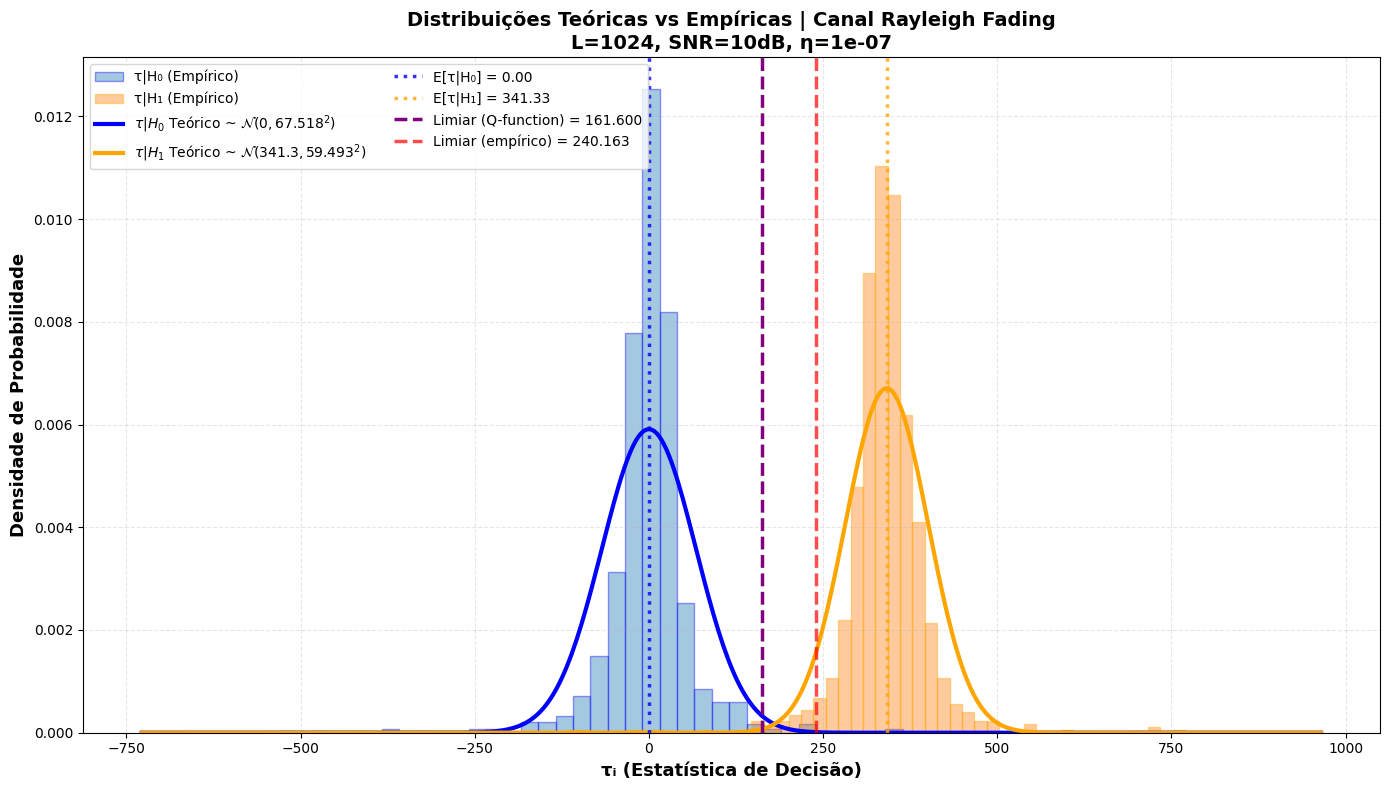

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import rayleigh
from scipy.integrate import quad

def plot_hist_teorico_empirico(K, L, N, snr_db, eta, rho_s):
    """
    Plota histogramas das distribuições empíricas (Monte Carlo) vs teóricas
    com canal Rayleigh fading.
    
    TEORIA CORRIGIDA:
    - τ|H₀ ~ N(0, σ²_v,H₀) sob H0 (atacante externo, canal h_fake)
    - τ|H₁ ~ N(L/3, σ²_v,H₁) sob H1 (usuário legítimo, canal h)
    
    Como H0 e H1 usam canais INDEPENDENTES (h ≠ h_fake), teoricamente
    poderiam ter variâncias diferentes. Porém, por simetria e expectativa,
    assumimos σ²_v,H₀ ≈ σ²_v,H₁. Usamos a variância empírica como estimativa.
    """
    # Calcula rho_t baseado na potência média da tag = 1/3
    rho_t = np.sqrt((1 - rho_s**2) * 3)  # Normaliza pela potência média da tag
    SNR = 10**(snr_db / 10)

    # Parâmetros do canal
    sigma_h = np.sqrt(1/2)          # Rayleigh: σ_h = 1/√2
    h_mean = sigma_h * np.sqrt(np.pi / 2)  # E[h] para Rayleigh
    sigma2w = 1 / SNR               # Variância do ruído AWGN normalizado

    # TAG: potência média 1/3
    sigma2tag = 1/3
    
    # Simular PRIMEIRO para obter estatísticas empíricas
    chave = np.random.randint(0, 2, K)
    
    stat_H1, stat_H0, threshold = simulate_hypothesis_test(
        L, K, N, rho_s, snr_db, chave, sigma2w, eta
    )
    
    # Variância empírica de cada hipótese
    var_empirica_H0 = np.var(stat_H0)
    var_empirica_H1 = np.var(stat_H1)
    sigma_v_H0 = np.sqrt(var_empirica_H0)
    sigma_v_H1 = np.sqrt(var_empirica_H1)
    #sigma_v_media = (sigma_v_H0 + sigma_v_H1) / 2  # Média para usar no threshold
    sigma2v = (sigma2tag * sigma2w * L) / ((rho_t * h_mean)**2) 
    # Médias condicionais (teóricas)
    mu_H0 = 0           # E[τ | H₀] = 0 (sem tag)
    mu_H1 = L / 3       # E[τ | H₁] = L × E[tag²] = L/3 (com tag)
    
    # Limiar de decisão (usando variância empírica média)
    tau_teorico = thresh(np.sqrt(sigma2v), 0, eta)
    #tau_teorico = thresh(sigma_v_H1, 0, eta)
    
    print(f"="*70)
    print("PARÂMETROS E ESTATÍSTICAS")
    print(f"="*70)
    print(f"ρ_s = {rho_s:.4f}, ρ_t = {rho_t:.4f}")
    print(f"σ²_w (ruído AWGN) = {sigma2w:.6f}")
    print(f"\nDesvios-padrão estimados (empírico, de {N} simulações):")
    print(f"σ_v,H₀ = {sigma_v_H0:.4f}")
    print(f"σ_v,H₁ = {sigma_v_H1:.4f}")
    print(f"σ_v (média) = {np.sqrt(sigma2v):.4f}")
    # Baseline AWGN (h = 1) para comparação percentual
    sigma_v_awgn = np.sqrt((sigma2tag * sigma2w * L) / (rho_t**2))
    percent_increase = (np.sqrt(sigma2v) - sigma_v_awgn) / sigma_v_awgn * 100
    print(f"σ_v AWGN (teórico, h=1) = {sigma_v_awgn:.4f}")
    print(f"Aumento percentual em σ_v vs AWGN: {percent_increase:.2f}%")
    print(f"\nSeparação (teórica) = {mu_H1 - mu_H0:.4f}")
    print(f"\nLimiar teórico (Q-function): {tau_teorico:.4f}")
    print(f"Limiar empírico (média dos limiares por transmissão): {np.mean(threshold):.4f}")

    # ---- Intervalo para plotar PDFs (compacto, focado nos dados) ----
    # Use o intervalo baseado nos percentis dos dados, não em 6*sigma_v
    x_min_data = min(stat_H0.min(), stat_H1.min())
    x_max_data = max(stat_H0.max(), stat_H1.max())
    
    # Expande um pouco além dos dados para visualizar as caudas das curvas normais
    margin = (x_max_data - x_min_data) * 0.15
    x_min = x_min_data - margin
    x_max = x_max_data + margin
    x = np.linspace(x_min, x_max, 500)

    # ---- PDFs teóricas com distribuição Normal ----
    # Sob H₀: τ|H₀ ~ N(0, σ²_v,H₀)
    # Sob H₁: τ|H₁ ~ N(L/3, σ²_v,H₁)
    pdf_H0 = norm.pdf(x, loc=mu_H0, scale=sigma_v_H0)
    pdf_H1 = norm.pdf(x, loc=mu_H1, scale=sigma_v_H1)

    # ---- Estatísticas da simulação ----
    print(f"\n{'='*70}")
    print("COMPARAÇÃO EMPÍRICO vs TEÓRICO")
    print(f"{'='*70}")
    print(f"E[τ|H₀] empírico: {np.mean(stat_H0):.4f} (teórico: {mu_H0:.4f})")
    print(f"E[τ|H₁] empírico: {np.mean(stat_H1):.4f} (teórico: {mu_H1:.4f})")
    print(f"Concordância média: {abs(np.mean(stat_H1) - mu_H1) / mu_H1 * 100:.2f}% de erro relativo")

    # ---- Plot ----
    plt.figure(figsize=(14, 8))

    # Histogramas empíricos
    plt.hist(stat_H0, bins=50, density=True, alpha=0.4, color='tab:blue', label='τ|H₀ (Empírico)', edgecolor='blue')
    plt.hist(stat_H1, bins=50, density=True, alpha=0.4, color='tab:orange', label='τ|H₁ (Empírico)', edgecolor='orange')

    # PDFs teóricas (normais com variâncias empíricas)
    plt.plot(x, pdf_H0, color='blue', linewidth=3, label=f'$\\tau|H_0$ Teórico ~ $\\mathcal{{N}}(0, {sigma_v_H0:.3f}^2)$')
    plt.plot(x, pdf_H1, color='orange', linewidth=3, label=f'$\\tau|H_1$ Teórico ~ $\\mathcal{{N}}({mu_H1:.1f}, {sigma_v_H1:.3f}^2)$')

    # Linhas de referência (médias teóricas)
    plt.axvline(mu_H0, color='blue', linestyle=':', linewidth=2.5, alpha=0.8, label=f'E[τ|H₀] = {mu_H0:.2f}')
    plt.axvline(mu_H1, color='orange', linestyle=':', linewidth=2.5, alpha=0.8, label=f'E[τ|H₁] = {mu_H1:.2f}')
    
    # Limiares de decisão
    plt.axvline(tau_teorico, color='purple', linestyle='--', linewidth=2.5, label=f'Limiar (Q-function) = {tau_teorico:.3f}')
    plt.axvline(np.mean(threshold), color='red', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Limiar (empírico) = {np.mean(threshold):.3f}')



    # Formatação
    plt.xlabel('τᵢ (Estatística de Decisão)', fontsize=13, fontweight='bold')
    plt.ylabel('Densidade de Probabilidade', fontsize=13, fontweight='bold')
    plt.title(f'Distribuições Teóricas vs Empíricas | Canal Rayleigh Fading\nL={L}, SNR={snr_db}dB, η={eta}', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

# Executa com parâmetros da simulação

plot_hist_teorico_empirico(1056, 1024, 10**3, 10, 0.0000001, np.sqrt(0.985))


##Trade-offs

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter
from tqdm.notebook import tqdm

def fnr_vs_L_theoretical(K, N, snr_db, eta, rho_s):
    """
    Curva teórica para FNR vs L com canal Rayleigh fading.
    
    MODELAGEM TEÓRICA:
    - τ|H₀ ~ N(0, σ²_v) onde σ²_v inclui o fator Rayleigh
    - τ|H₁ ~ N(L/3, σ²_v) sob H₁
    - O fator multiplicativo h do Rayleigh afeta a variância
    - Usa E[h] = √(π/2) × σ_h para o cálculo teórico
    """
    rho_t = np.sqrt((1 - rho_s**2)*3)
    SNR = 10**(snr_db / 10)
    sigma2w = 1 / SNR  # Variância do ruído AWGN normalizada
    
    L_max = K
    L_values = range(32, L_max, 32)
    fnr_prob = []
    
    # Valor esperado do fator Rayleigh: E[h] = √(π/2) × σ_h
    # onde σ_h = 1/√2, então E[h] ≈ 0.887
    sigma_h = 1/np.sqrt(2)
    h_mean = np.sqrt(np.pi/2) * sigma_h
    #h_mean=1
    
    for L in tqdm(L_values, desc="Calculando Prob Falso Negativo teórico (Rayleigh)", unit="L"):
        sigma2tag = 1/3
        
        # Variância com fator Rayleigh multiplicativo
        # σ²_v = (σ²_tag × σ²_w × L) / (ρ_t × E[h])²
        sigma2v = (sigma2tag * sigma2w * L) / ((rho_t * h_mean)**2)
        
        # Limiar de decisão para PFA = eta (False Alarm Rate)
        tau = thresh(np.sqrt(sigma2v), 0, eta) 
        #tau = find_threshold_to_reduce_fp([L/3], [0], eta)  # Limiar baseado na separação teórica
        
        # Probabilidade de Falso Negativo (não detectar tag legítima)
        # P(τ < τ₀ | H₁) = Q((τ - E[τ|H₁]) / σ_v)
        prob = 1 - Qfunc((tau - (L/3)) / np.sqrt(sigma2v))
        fnr_prob.append(prob)

    return fnr_prob




In [14]:
def fnr_vs_L_MonteCarlo(K, N, snr_db, eta, rho_s):
    """
    Simulação Monte Carlo para FNR vs L com canal Rayleigh fading.
    
    """
    L_max = K
    L_values = range(32, L_max, 32)
    fnr_values = []

    for L in tqdm(L_values, desc="Calculando FNR Monte Carlo com Rayleigh", unit="L"):
        fnr = 0

        for i in range(50):
            # Gera chave e sigma2w como no notebook sem Rayleigh
            chave = np.random.randint(0, 2, L+32)
            sigma2w, _ = gen_awgn(snr_db, L)

            # Chama simulate com K = L+32 para compatibilidade
            stat_H1, stat_H0, thresh = simulate_hypothesis_test(L, L+32, N, rho_s, snr_db, chave, sigma2w, eta)

            y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
            y_scores = np.concatenate([stat_H1, stat_H0])
            tau_vec = np.array([thresh[j % len(thresh)] for j in range(len(y_scores))])
            y_pred = (y_scores >= tau_vec).astype(int)
            cm = confusion_matrix(y_true, y_pred, labels=[0,1])
            TN, FP, FN, TP = cm.ravel()
            # Acumula FNR (False Negative Rate) das 50 simulações
            fnr += (FN / len(stat_H1)) / 50
        
        fnr_values.append(fnr)

    return fnr_values

In [15]:
auth_prob = fnr_vs_L_theoretical(512, 10**3, 10, 0.0000001, np.sqrt(0.985))
np.savez("fnr_teorico_Rayleigh_hRandom104.npz", auth_prob=auth_prob)


Calculando Prob Falso Negativo teórico (Rayleigh):   0%|          | 0/15 [00:00<?, ?L/s]

In [ ]:
fnr_values = fnr_vs_L_MonteCarlo(512, 10**3, 10, 0.0000001, np.sqrt(0.985))
np.savez("fnr_MonteCarlo_Rayleigh_hRandom104.npz", fnr_values=fnr_values)


Calculando FNR Monte Carlo com Rayleigh:   0%|          | 0/15 [00:00<?, ?L/s]

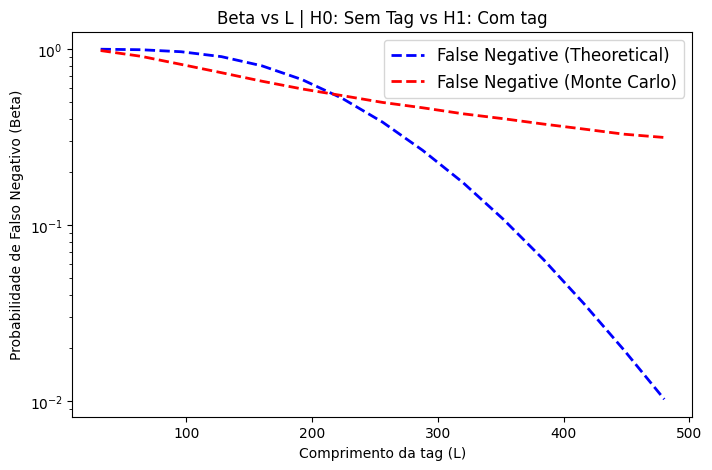

In [ ]:
#data = np.load("resultados_auth_fnr.npz")
L_values = range(32, 512, 32)
auth_prob = np.load("fnr_teorico_Rayleigh_hRandom104.npz")["auth_prob"]
fnr_values = np.load("fnr_MonteCarlo_Rayleigh_hRandom104.npz")["fnr_values"]
# Plot
plt.figure(figsize=(8, 5))
plt.semilogy(L_values, auth_prob,  '--b', linewidth=2, label='False Negative (Theoretical)')
plt.semilogy(L_values, fnr_values, '--r', linewidth=2, label='False Negative (Monte Carlo)')
plt.xlabel("Comprimento da tag (L)")
plt.ylabel("Probabilidade de Falso Negativo (Beta)")
plt.title("Beta vs L | H0: Sem Tag vs H1: Com tag")
plt.legend(loc='best', fontsize=12, frameon=True)
plt.show()